In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
from pathlib import Path
import pandas as pd
import os
import results_analysis_utils as rutils
import matplotlib.pyplot as plt
import seaborn as sn

%load_ext autoreload
%autoreload 2


# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 200 # Alta resolución
plt.rcParams['savefig.dpi'] = 200

one_fish_gt = {"2024_11_12":31.5, "2024_11_28":28.9,"2025_05_08":33.5,"2025_08_21":29.1}

# Choose video day
folder_code ="2024_11_12"

# Parámetros Globales
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
ASPECT_RATIO_THR = 3.0
ANGLE_THR = 20.0

df=[]

cprint(f"Processing fish videos recorded on the date {folder_code} ","blue")
cprint(f"ROOT DIR IS {ROOT_DIR} ","blue")

gt = one_fish_gt[folder_code]
cprint(f"✅ Ground Truth is the same for all videos with a single fish: {gt}","magenta")



Processing fish videos recorded on the date 2024_11_12 
ROOT DIR IS /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12 
✅ Ground Truth is the same for all videos with a single fish: 31.5


In [2]:

folder_code ="2024_11_12"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code

df_raw_agg_2024_11_12 =rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])

folder_code ="2024_11_28"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
df_raw_agg_2024_11_28 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])


folder_code ="2025_05_08"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
df_raw_agg_2025_05_08 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])

# Lista de DataFrames
dfs = [
    df_raw_agg_2024_11_12,
    df_raw_agg_2024_11_28,
    df_raw_agg_2025_05_08
]

# Concatenar verticalmente (apilarlos)
df_raw_agg_pool = pd.concat(dfs, axis=0, ignore_index=True)

# Revisar
print(df_raw_agg_pool.shape)
print(df_raw_agg_pool.head())

folder_code ="2025_08_21"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
df_raw_agg_2025_08_21 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])


df_raw_agg_2025_08_21.head()



Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_44_11/0/results_article_basic_nou/corrected_results/10_44_11_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_54_07/0/results_article_basic_nou/corrected_results/10_54_07_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_10_50/0/results_article_basic_nou/corrected_results/11_10_50_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_00_27/0/results_article_basic_nou/corrected_results/11_00_27_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_58_20/0/results_article_basic_nou/corrected_results/10_58_20_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,2025_08_21,12_09_03,frame_0,0,255,1,-1,False,False,True,...,NaN,67.619721,37.106544,-1.0,0.322840,0.316668,29.1,3.184030,11.709446,1.663082
1,2025_08_21,12_09_03,frame_1,0,255,1,-1,False,False,True,...,NaN,66.080659,37.133779,-1.0,0.308119,0.328139,29.1,1.711855,6.615414,1.659265
2,2025_08_21,12_09_03,frame_2,0,255,1,-1,False,False,True,...,NaN,50.109826,25.106295,-1.0,0.249701,0.228324,29.1,4.129863,13.598142,1.693085
3,2025_08_21,12_09_03,frame_3,0,255,1,-1,False,False,True,...,NaN,58.247246,14.057908,-1.0,0.300613,0.282332,29.1,0.961328,4.018435,1.678158
4,2025_08_21,12_09_03,frame_4,0,255,1,-1,False,False,True,...,NaN,44.696387,13.541004,-1.0,0.257552,0.244369,29.1,3.344761,10.881526,1.710066


In [3]:

df_3d_measures=df_raw_agg[df_raw_agg["filtered_length"] > 0]


cprint(df_raw_agg.describe(),"red")
cprint(df_3d_measures.describe(),"green")
output_path = Path(ROOT_DIR) / f"{folder_code}_raw_3d_aggregated.csv"

df_3d_measures.to_csv(output_path, index=False)
 
df_3d_measures.head()



NameError: name 'df_raw_agg' is not defined

In [ ]:
# Checks!

# Number of video seqs loaded:
video_codes = df_raw_agg["source_folder"].unique()
cprint(f"Number of video seqs is: {len(video_codes)}","yellow")
 
cprint("\n Unique video codes are","cyan")
for code in video_codes:
    cprint(code+ "\n","cyan")

Number of video seqs is: 9

 Unique video codes are
10_44_11-0

10_54_07-0

11_10_50-0

11_00_27-0

10_58_20-0

11_08_39-0

11_37_10-0

10_48_44-1

10_48_44-0



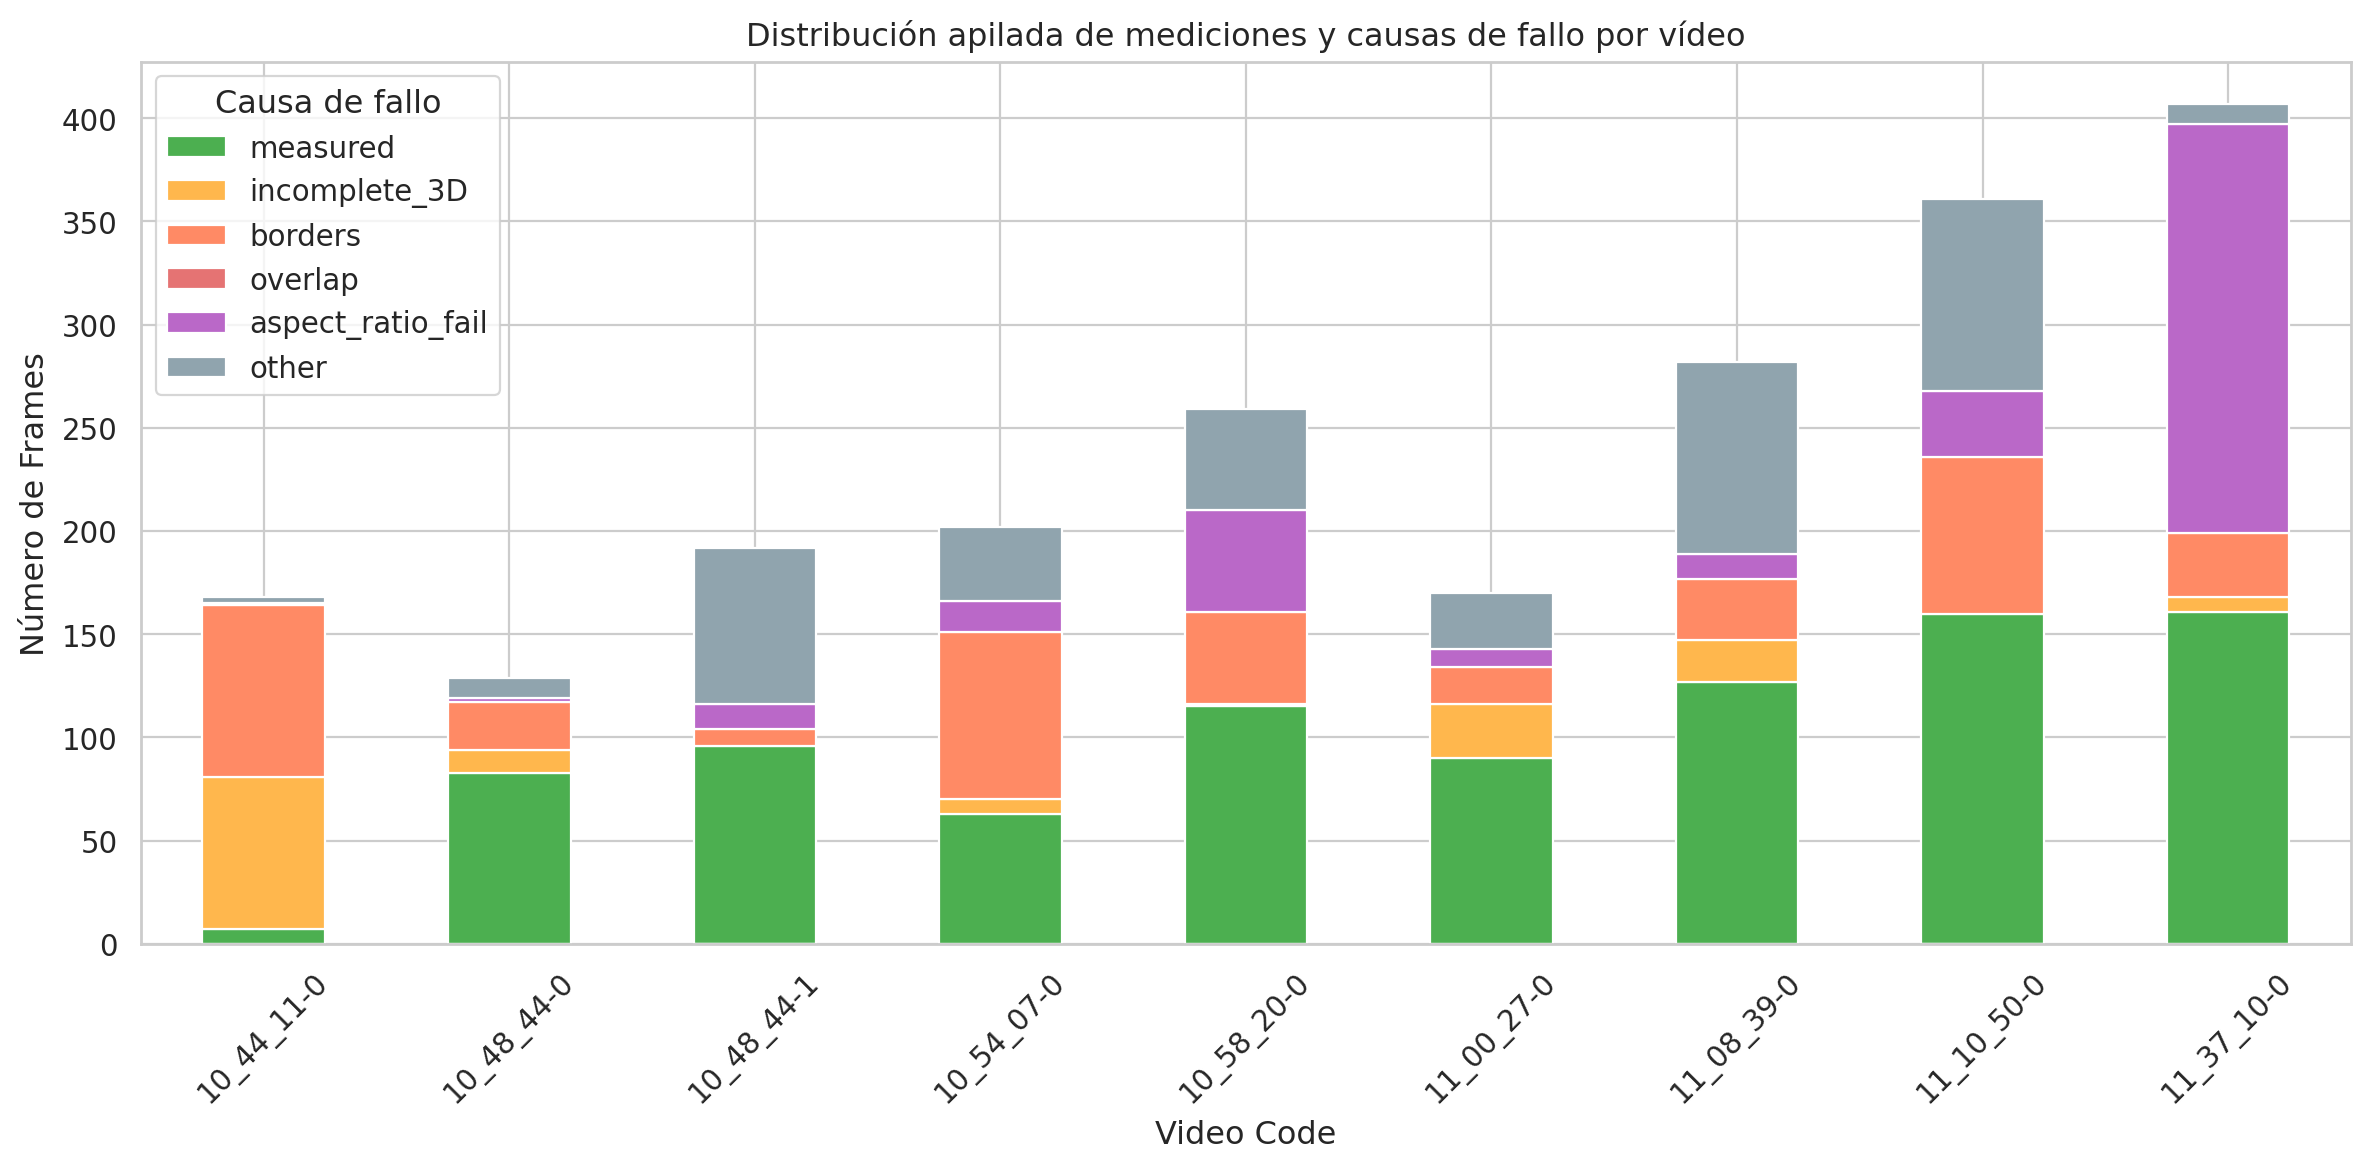

Conteo global de frames por causa:
      failure_reason  count
0           measured    902
1      incomplete_3D    146
2            borders    395
3            overlap      0
4  aspect_ratio_fail    330
5              other    397


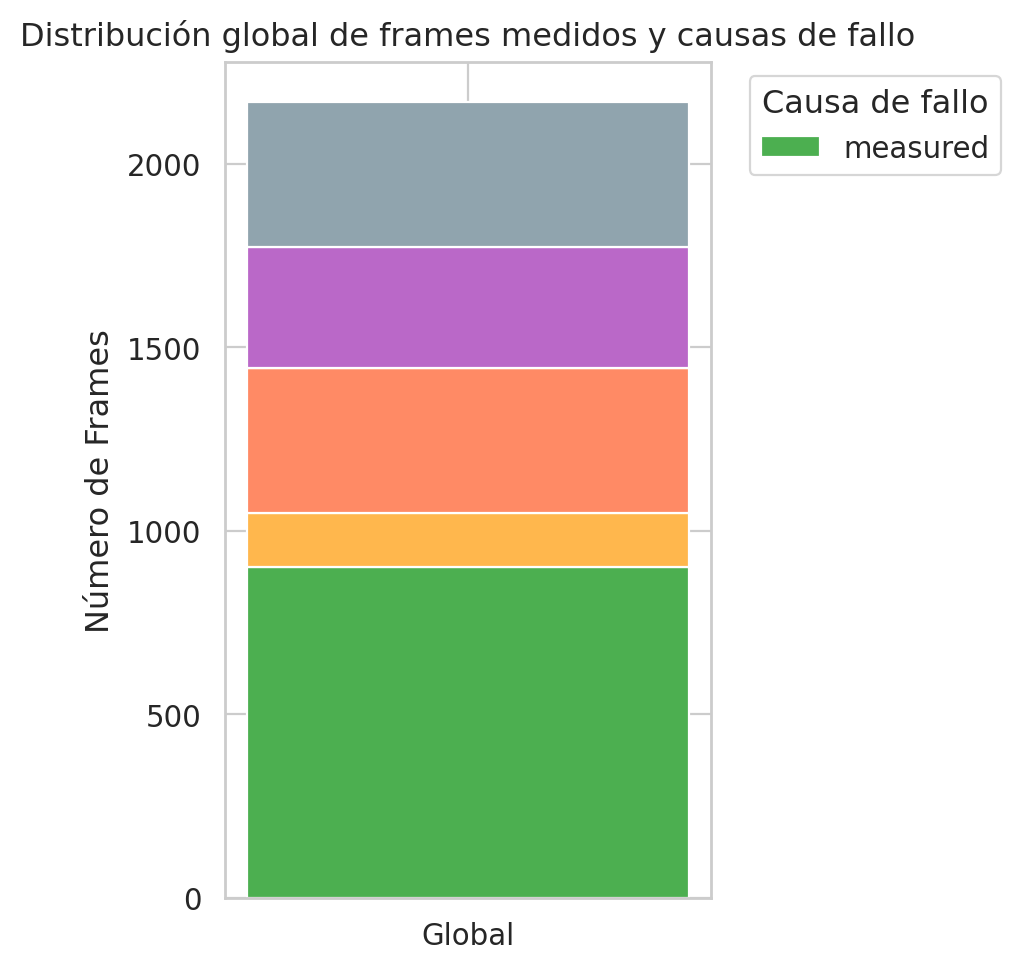

failure_reason,measured,incomplete_3D,borders,overlap,aspect_ratio_fail,other
source_folder,,,,,,
10_44_11-0,7,74,83,0,1,3
10_48_44-0,83,11,23,0,2,10
10_48_44-1,96,0,8,0,12,76
10_54_07-0,63,7,81,0,15,36
10_58_20-0,115,1,45,0,49,49
11_00_27-0,90,26,18,0,9,27
11_08_39-0,127,20,30,0,12,93
11_10_50-0,160,0,76,0,32,93
11_37_10-0,161,7,31,0,198,10


In [ ]:


df_raw_agg['unique_track'] = df_raw_agg['source_folder'].astype(str) + "_" + df_raw_agg['track_id'].astype(str)
df_raw_agg["failure_reason"] = df_raw_agg.apply(
    lambda row: rutils.classify_failure(row, ASPECT_RATIO_THR=ASPECT_RATIO_THR),
    axis=1
)


rutils.plot_frame_failures(df_raw_agg, figsize_video=(12,6), figsize_global=(5,5), show_global=True)

rutils.plot_tracks_failure_distribution(df_raw_agg, aspect_ratio_thr=3.0, show_global=True, figsize_video=(12,6), figsize_global=(5,5))
rutils.plot_aspect_ratio_vs_length(df_raw_agg, ASPECT_RATIO_THR=ASPECT_RATIO_THR, figsize=(10, 8))

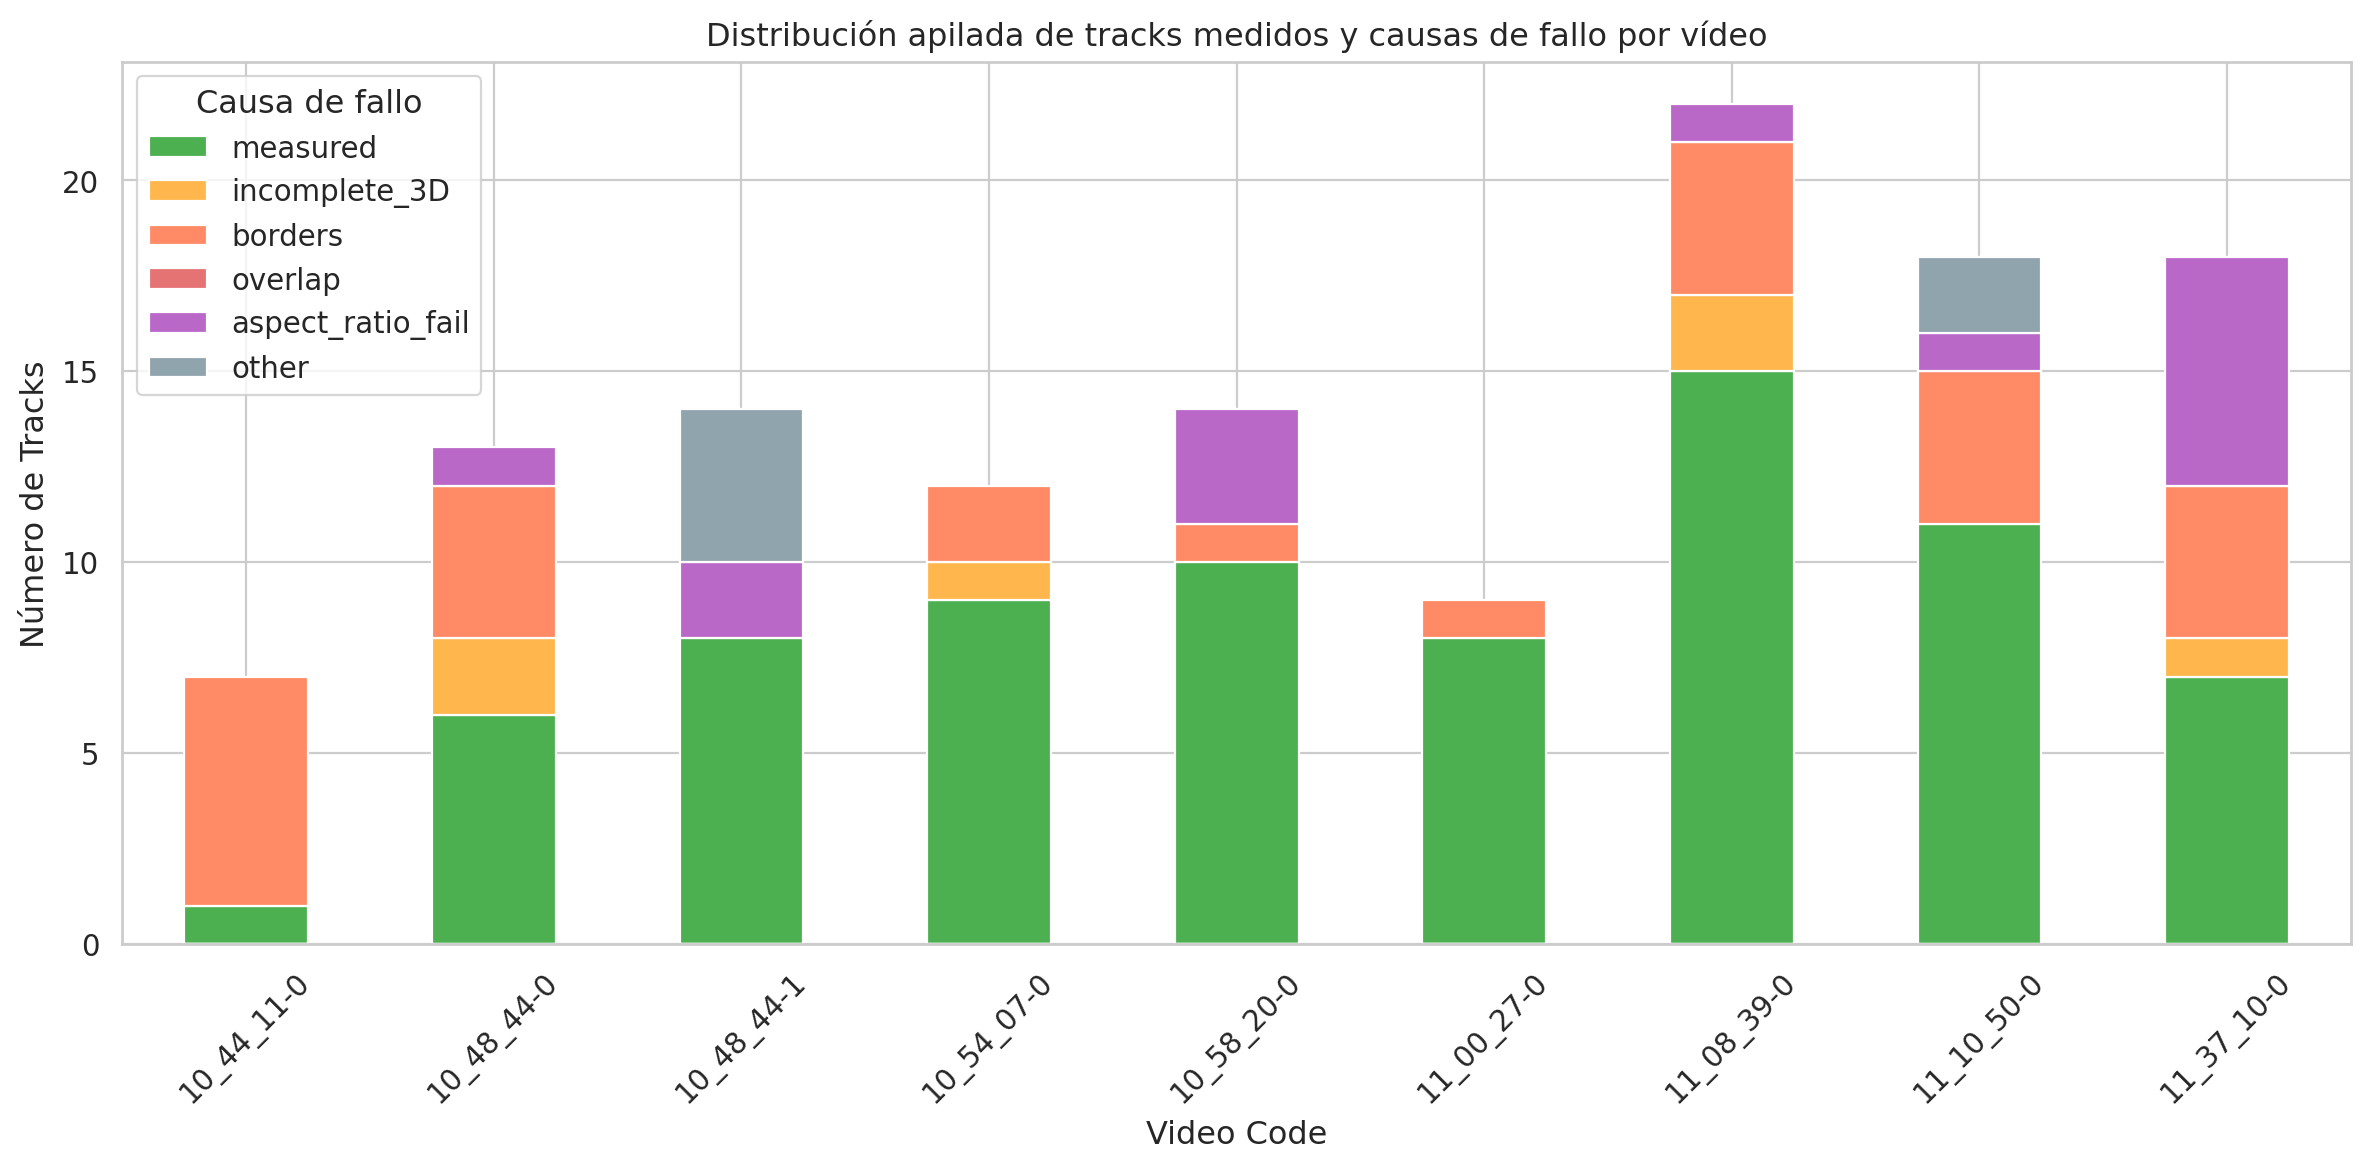

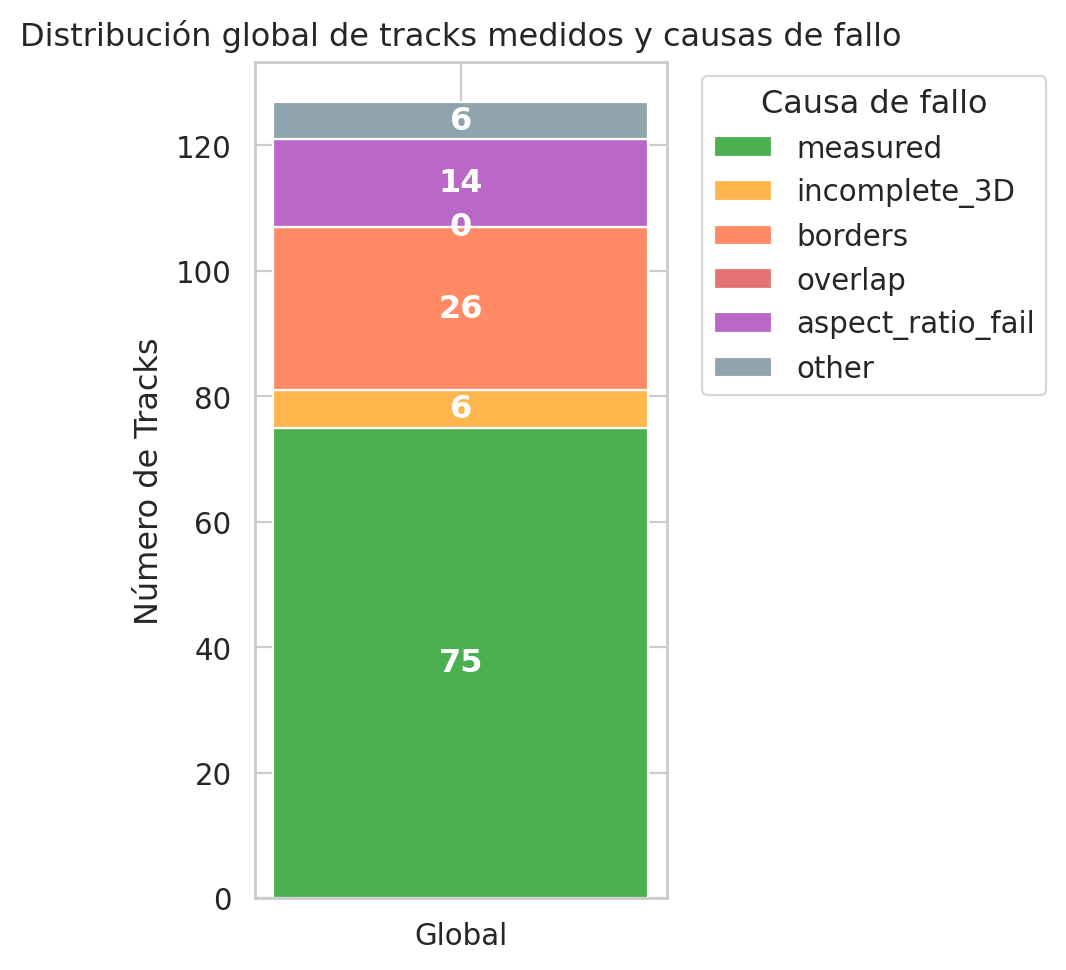

,unique_track,track_failure_reason,source_folder
0,10_44_11-0_-1,borders,10_44_11-0
1,10_44_11-0_13,borders,10_44_11-0
2,10_44_11-0_15,borders,10_44_11-0
3,10_44_11-0_3,measured,10_44_11-0
4,10_44_11-0_7,borders,10_44_11-0
...,...,...,...
122,11_37_10-0_4,aspect_ratio_fail,11_37_10-0
123,11_37_10-0_41,aspect_ratio_fail,11_37_10-0
124,11_37_10-0_44,measured,11_37_10-0
125,11_37_10-0_45,measured,11_37_10-0


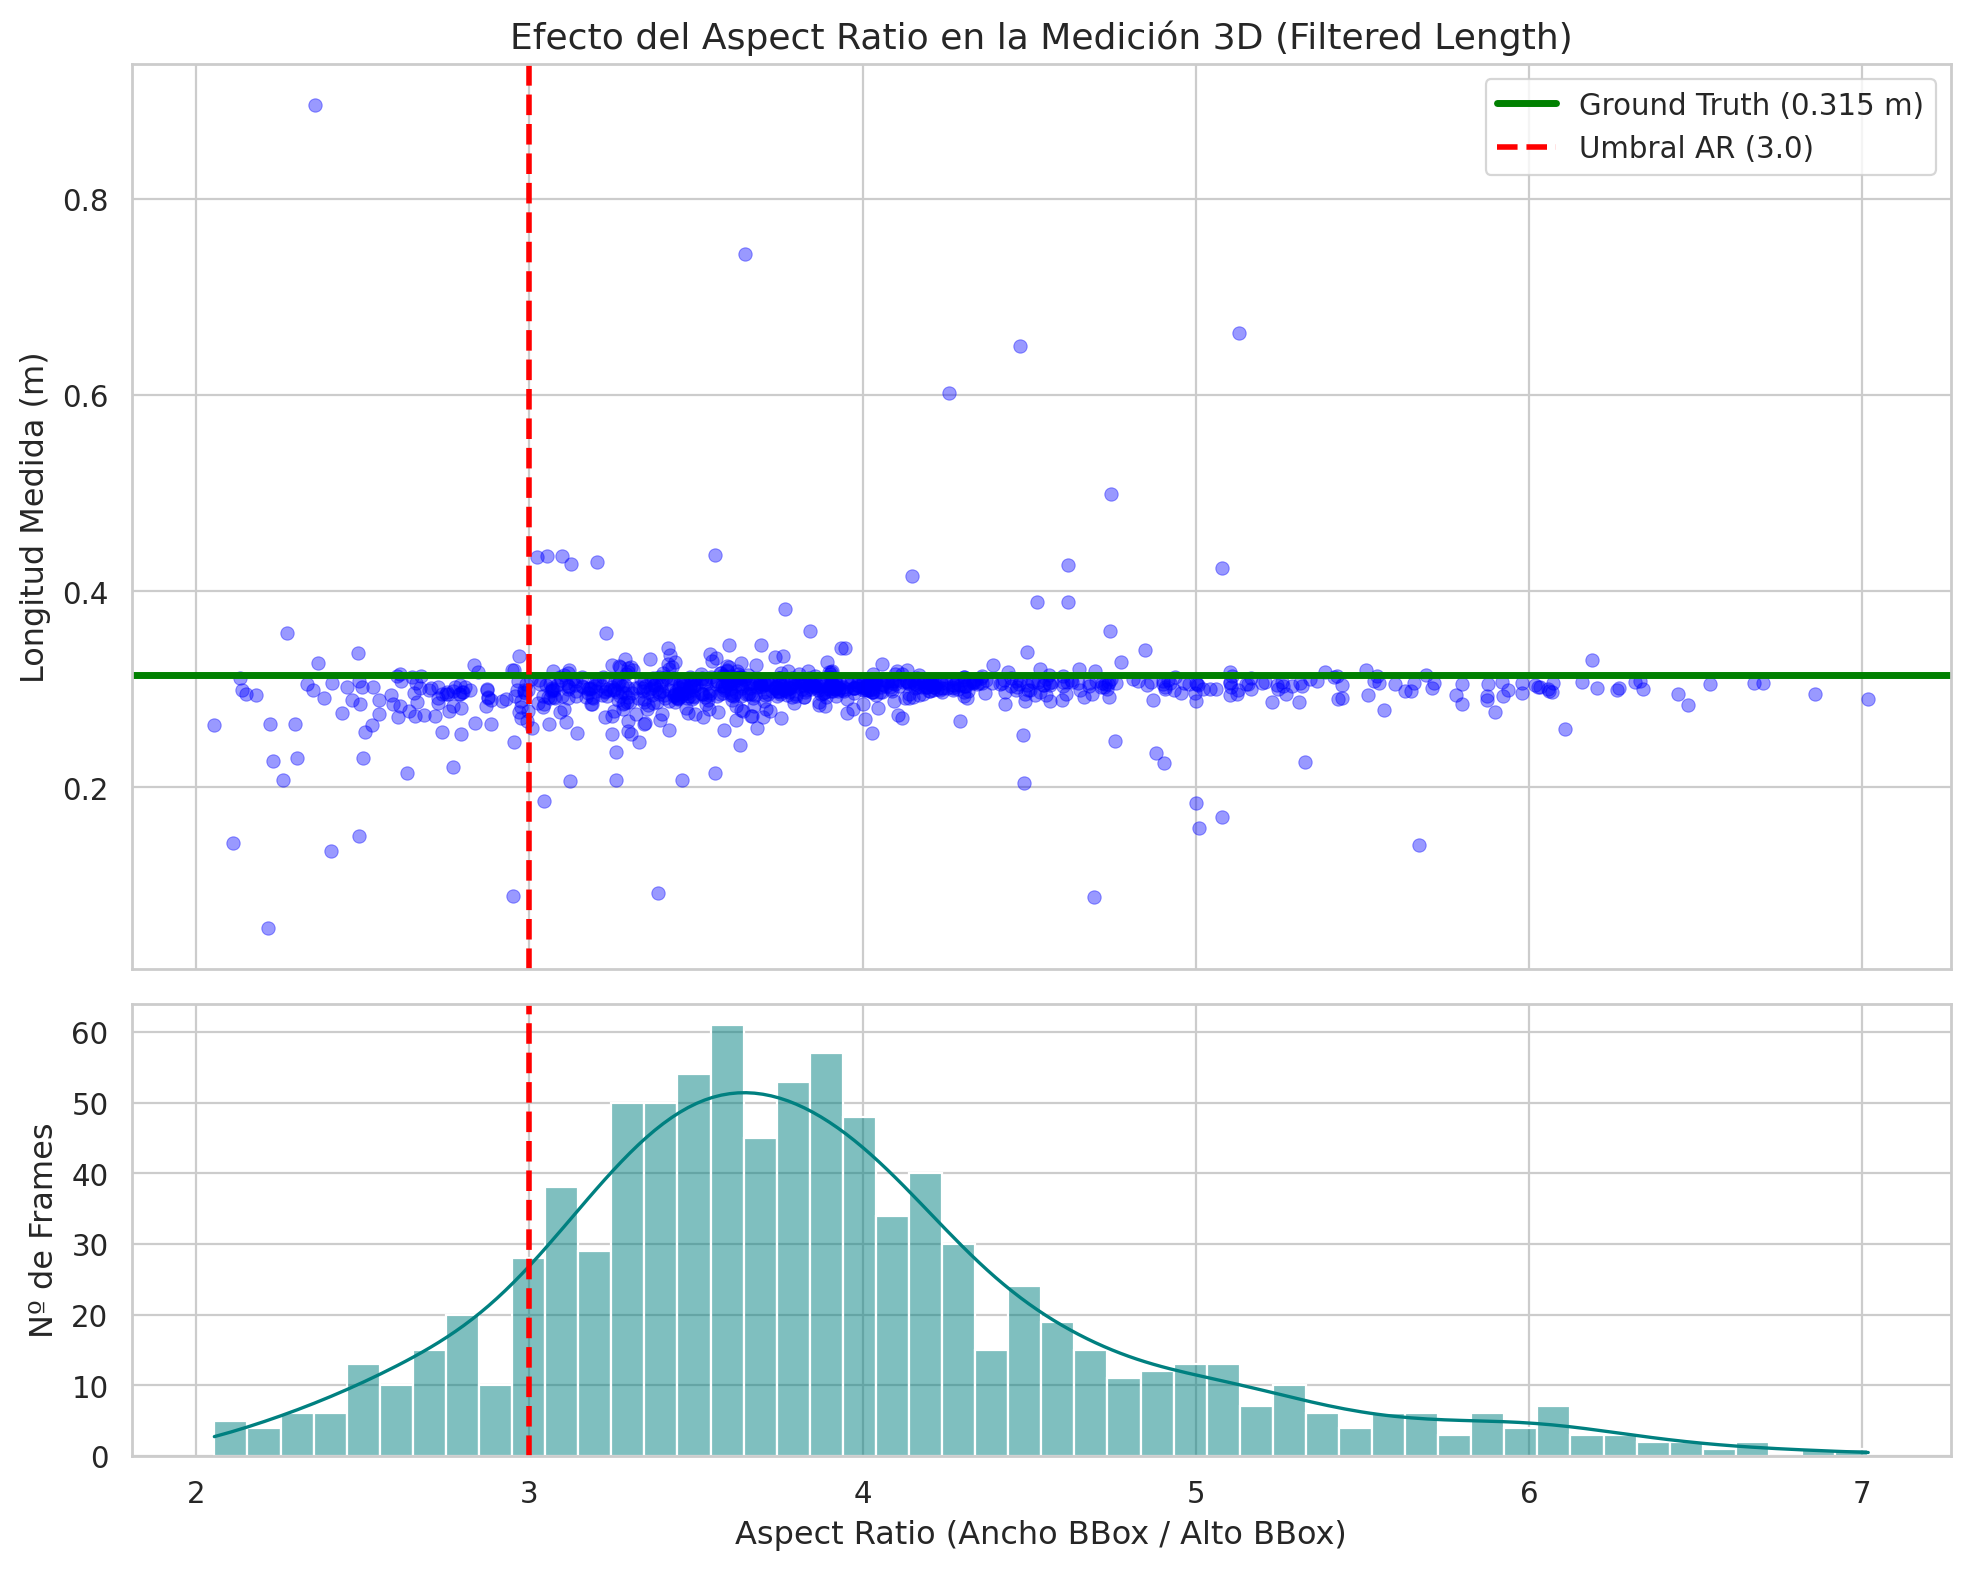

DF NAME IS df_raw_agg_2024_11_12
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  1.51 ± 2.41 cm |     902 frames |    44 tracks
2. + Filtro: Sin Bordes                       |  1.51 ± 2.41 cm |     902 frames |    44 tracks
3. + Filtro: Sin Solapamiento                 |  1.51 ± 2.41 cm |     902 frames |    44 tracks
4. + Filtro: Aspect Ratio >= 3.0              |  1.05 ± 1.14 cm |     795 frames |    39 tracks
5. + Filtro: Ángulo Z <= 20.0º                |  1.26 ± 2.97 cm |     409 frames |    26 tracks
6. + Filtro: is_3D_complete                   |  1.26 ± 2.97 cm |     409 frames |    26 tracks


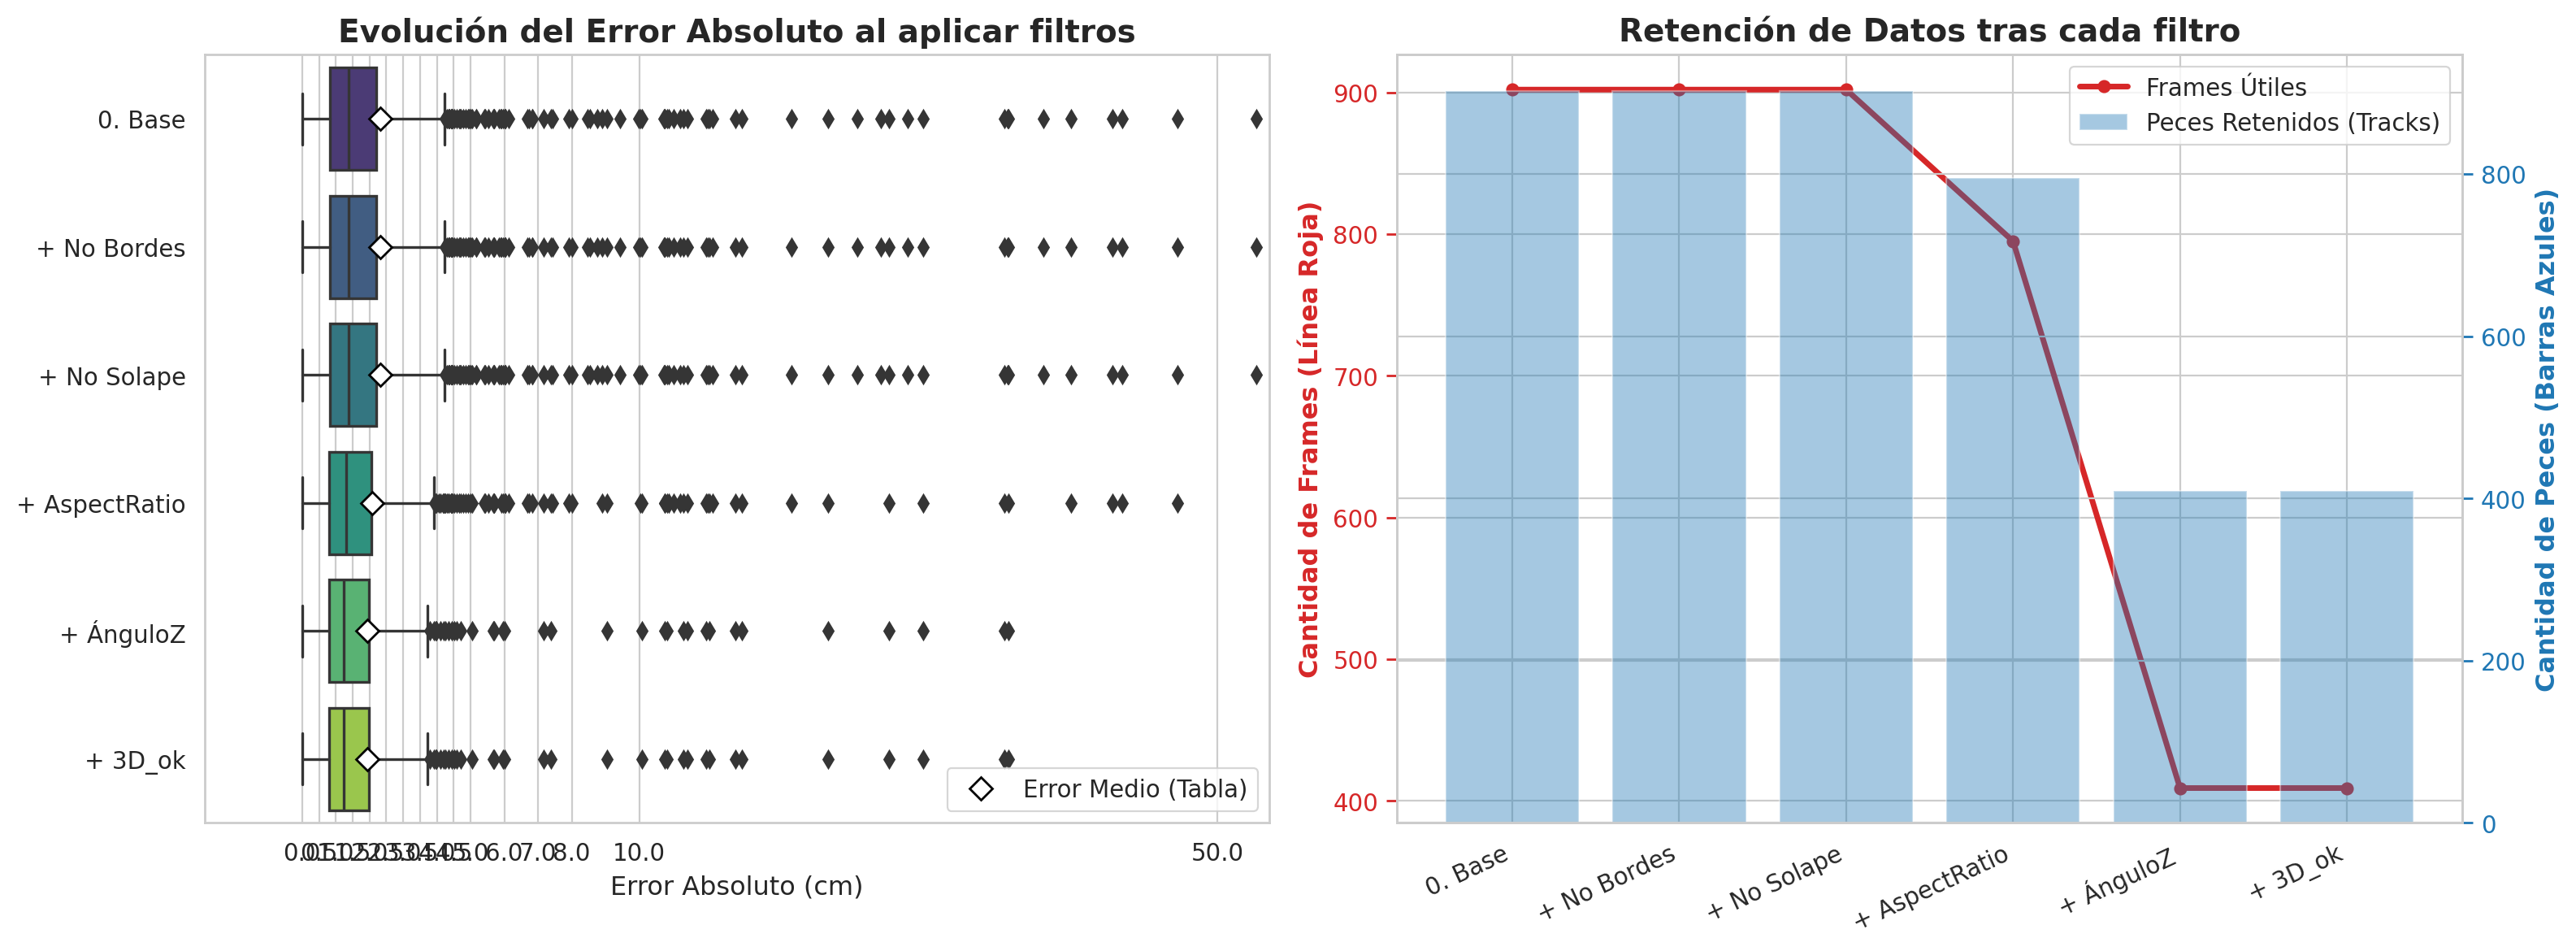

DF NAME IS df_raw_agg_2024_11_28
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  3.54 ± 7.42 cm |    3216 frames |    52 tracks
2. + Filtro: Sin Bordes                       |  2.07 ± 4.05 cm |    2996 frames |    46 tracks
3. + Filtro: Sin Solapamiento                 |  2.07 ± 4.05 cm |    2996 frames |    46 tracks
4. + Filtro: Aspect Ratio >= 3.0              |  1.73 ± 3.29 cm |    2876 frames |    45 tracks
5. + Filtro: Ángulo Z <= 20.0º                |  0.69 ± 1.03 cm |    2098 frames |    34 tracks
6. + Filtro: is_3D_complete                   |  0.69 ± 1.03 cm |    2098 frames |    34 tracks


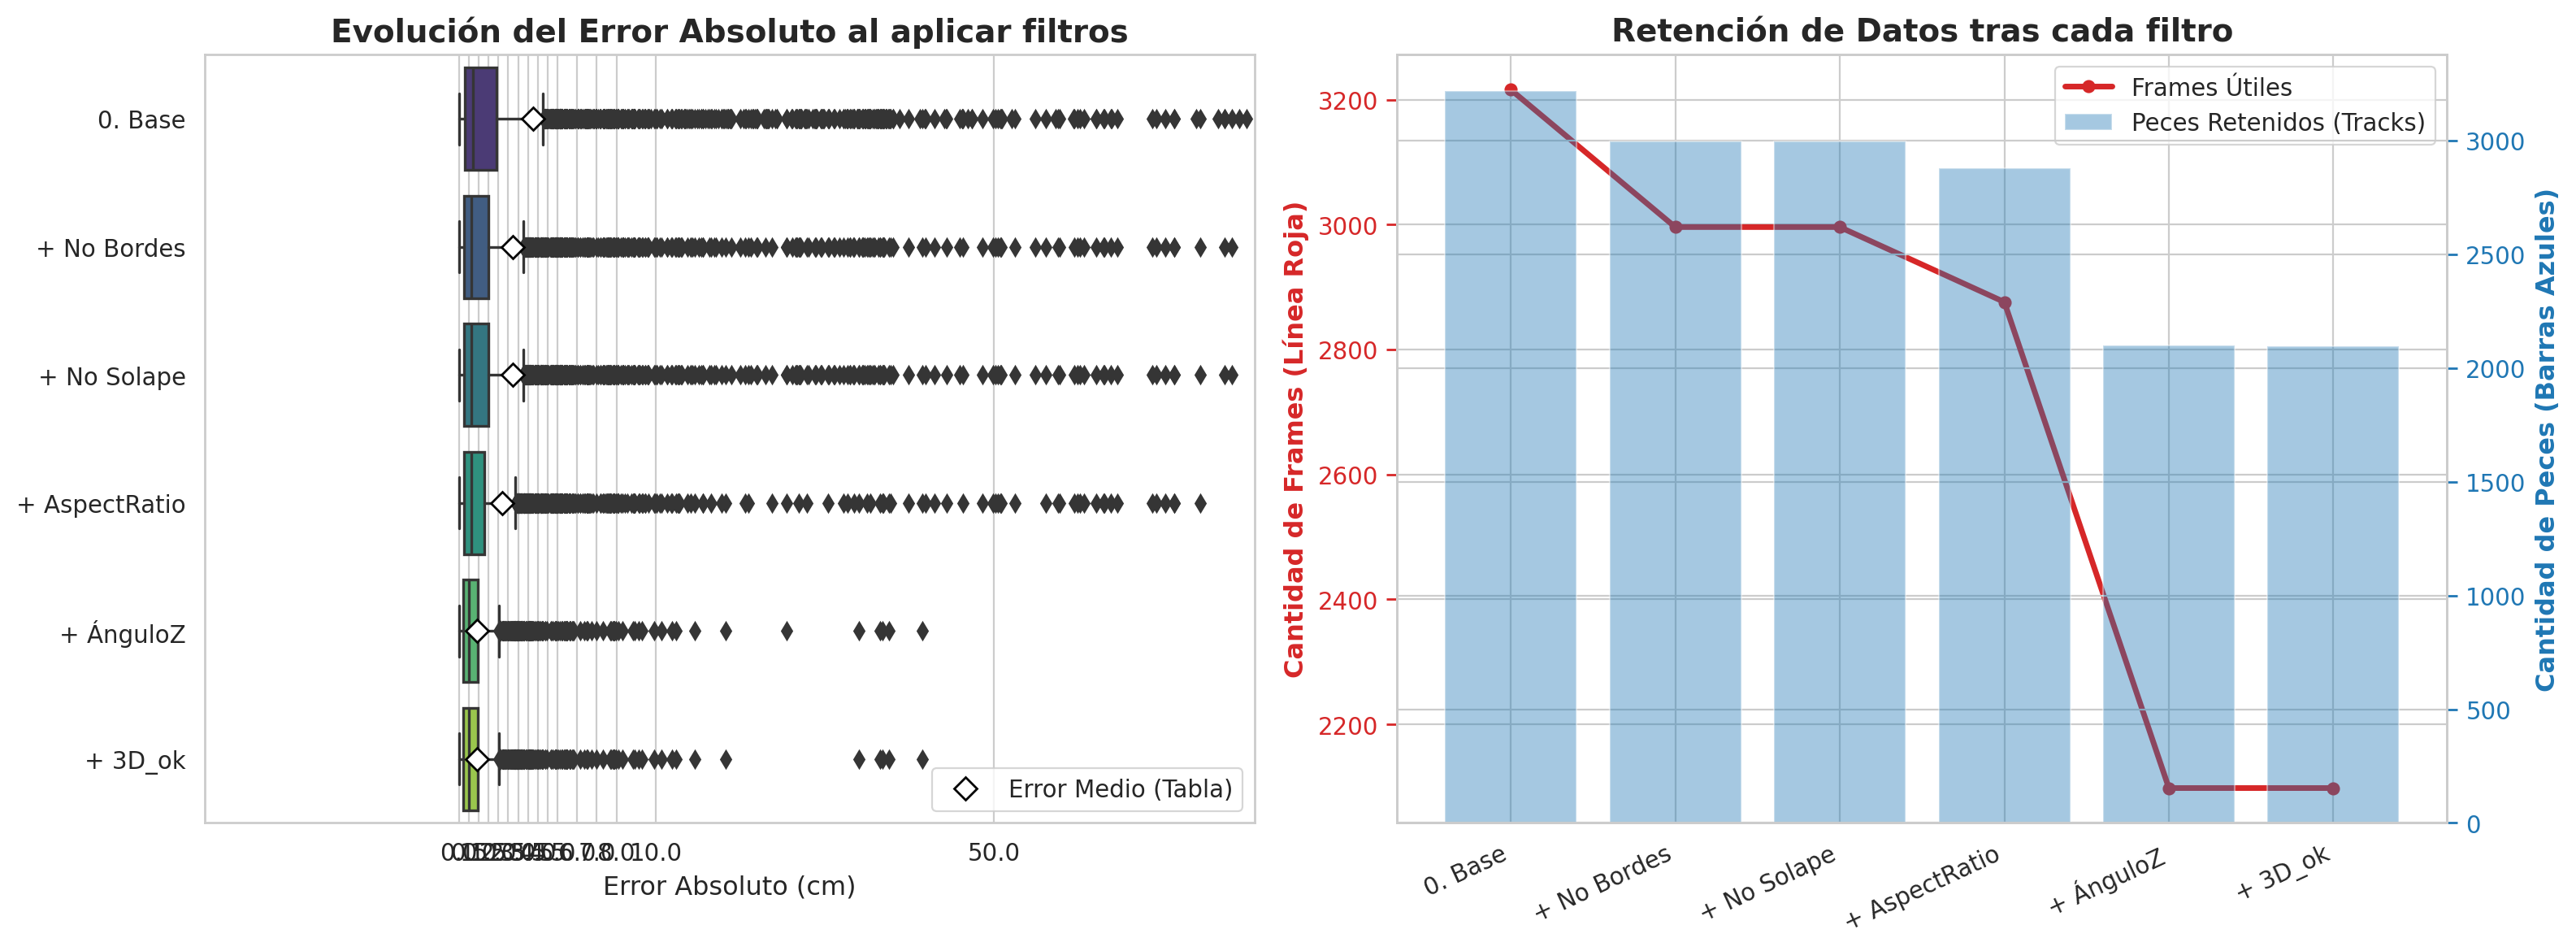

DF NAME IS df_raw_agg_2025_05_08
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  2.64 ± 1.72 cm |     134 frames |     3 tracks
2. + Filtro: Sin Bordes                       |  2.64 ± 1.72 cm |     134 frames |     3 tracks
3. + Filtro: Sin Solapamiento                 |  2.64 ± 1.72 cm |     134 frames |     3 tracks
4. + Filtro: Aspect Ratio >= 3.0              |  2.75 ± 1.56 cm |     116 frames |     3 tracks
5. + Filtro: Ángulo Z <= 20.0º                |  2.15 ± 0.85 cm |      87 frames |     2 tracks
6. + Filtro: is_3D_complete                   |  2.15 ± 0.85 cm |      87 frames |     2 tracks


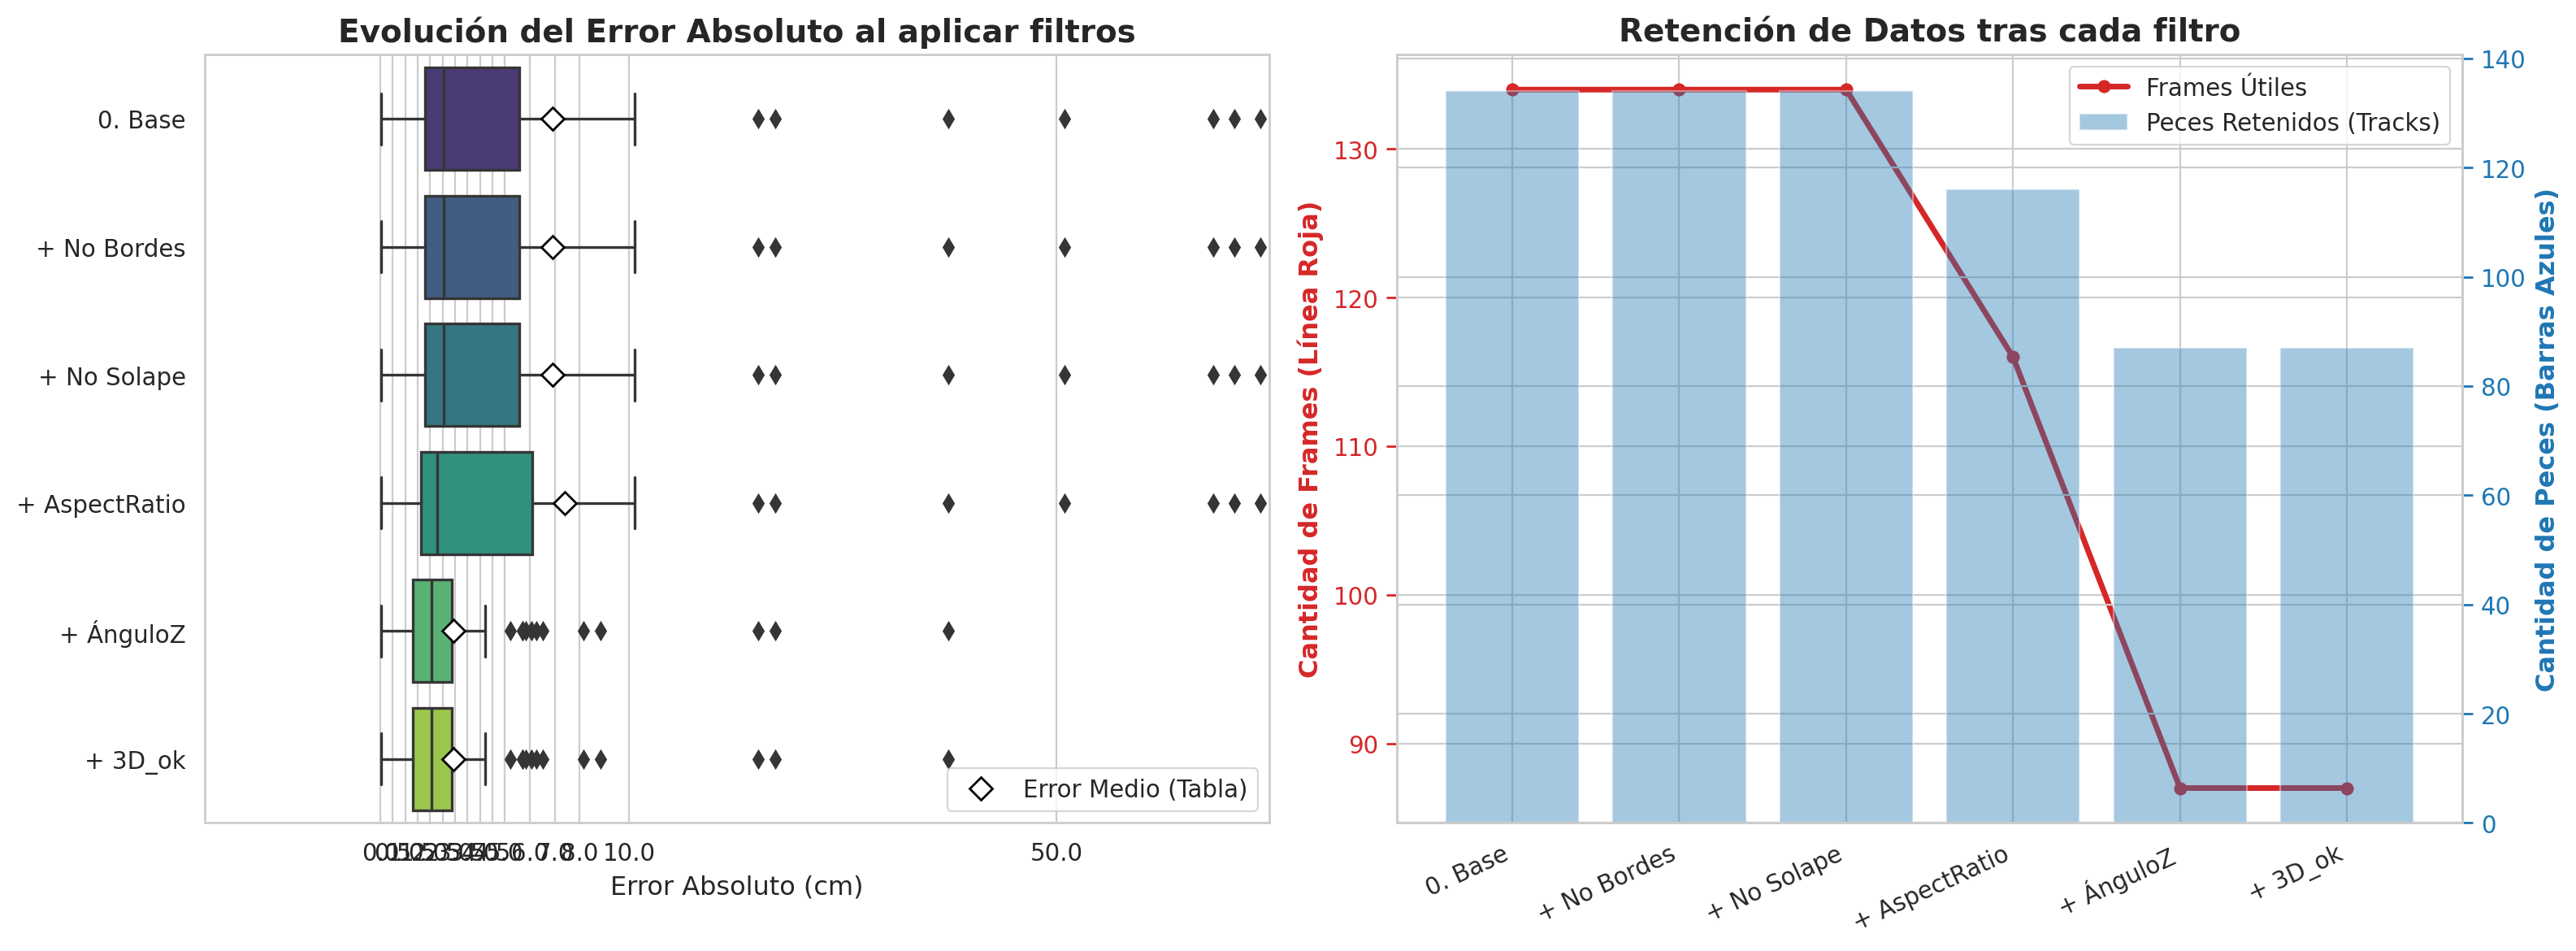

DF NAME IS df_raw_agg_2025_08_21
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  4.23 ± 3.77 cm |   14295 frames |    48 tracks
2. + Filtro: Sin Bordes                       |  4.23 ± 3.77 cm |   14295 frames |    48 tracks
3. + Filtro: Sin Solapamiento                 |  4.24 ± 3.79 cm |   14278 frames |    48 tracks
4. + Filtro: Aspect Ratio >= 3.0              |  2.88 ± 3.27 cm |    5941 frames |    30 tracks
5. + Filtro: Ángulo Z <= 20.0º                |  1.28 ± 1.79 cm |    1109 frames |    24 tracks
6. + Filtro: is_3D_complete                   |  1.28 ± 1.79 cm |    1109 frames |    24 tracks


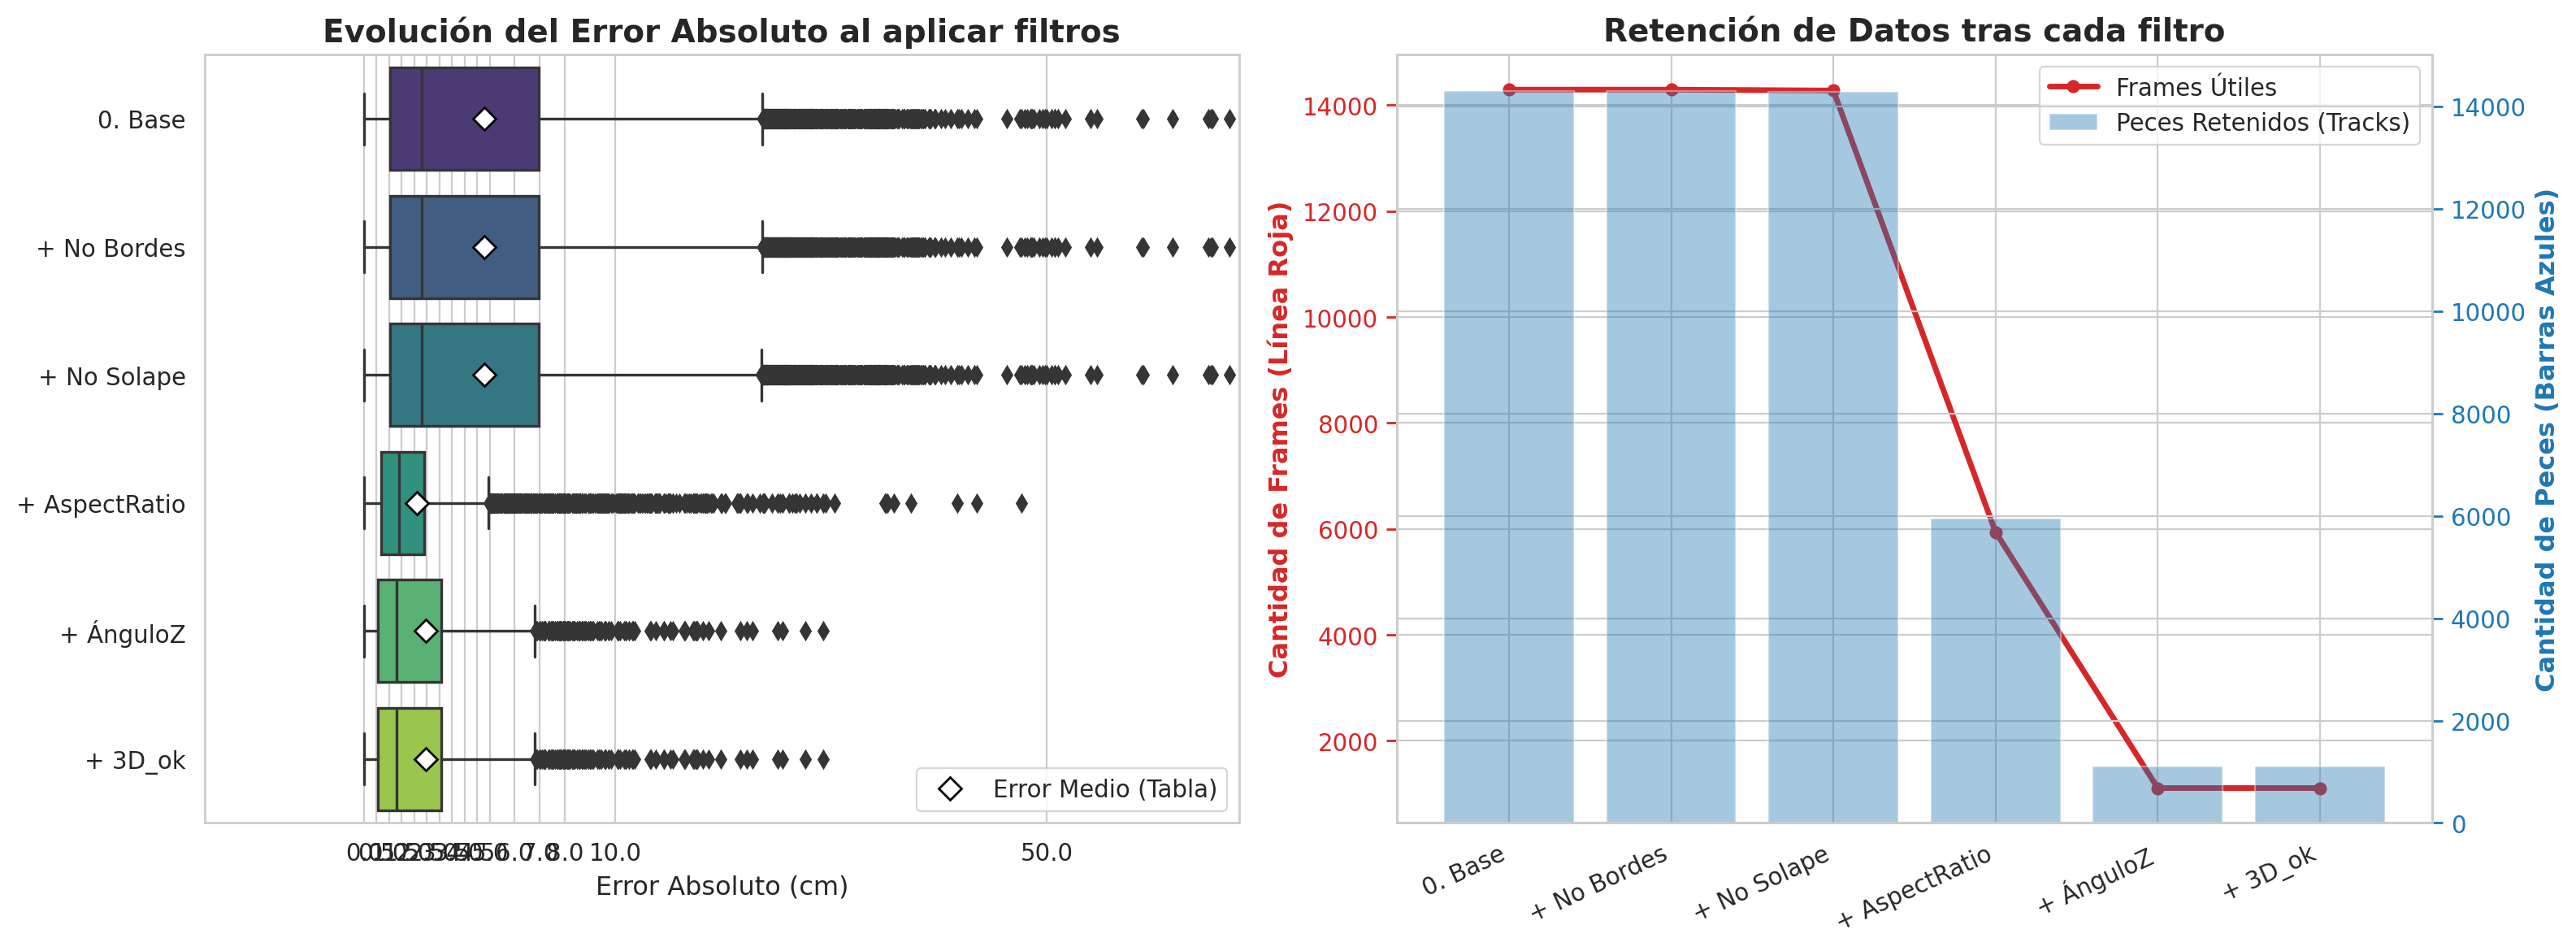

DF NAME IS df_raw_agg_pool
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  2.61 ± 5.68 cm |    4252 frames |    99 tracks
2. + Filtro: Sin Bordes                       |  1.82 ± 3.30 cm |    4032 frames |    93 tracks
3. + Filtro: Sin Solapamiento                 |  1.82 ± 3.30 cm |    4032 frames |    93 tracks
4. + Filtro: Aspect Ratio >= 3.0              |  1.46 ± 2.52 cm |    3787 frames |    87 tracks
5. + Filtro: Ángulo Z <= 20.0º                |  0.98 ± 2.08 cm |    2594 frames |    62 tracks
6. + Filtro: is_3D_complete                   |  0.98 ± 2.08 cm |    2594 frames |    62 tracks


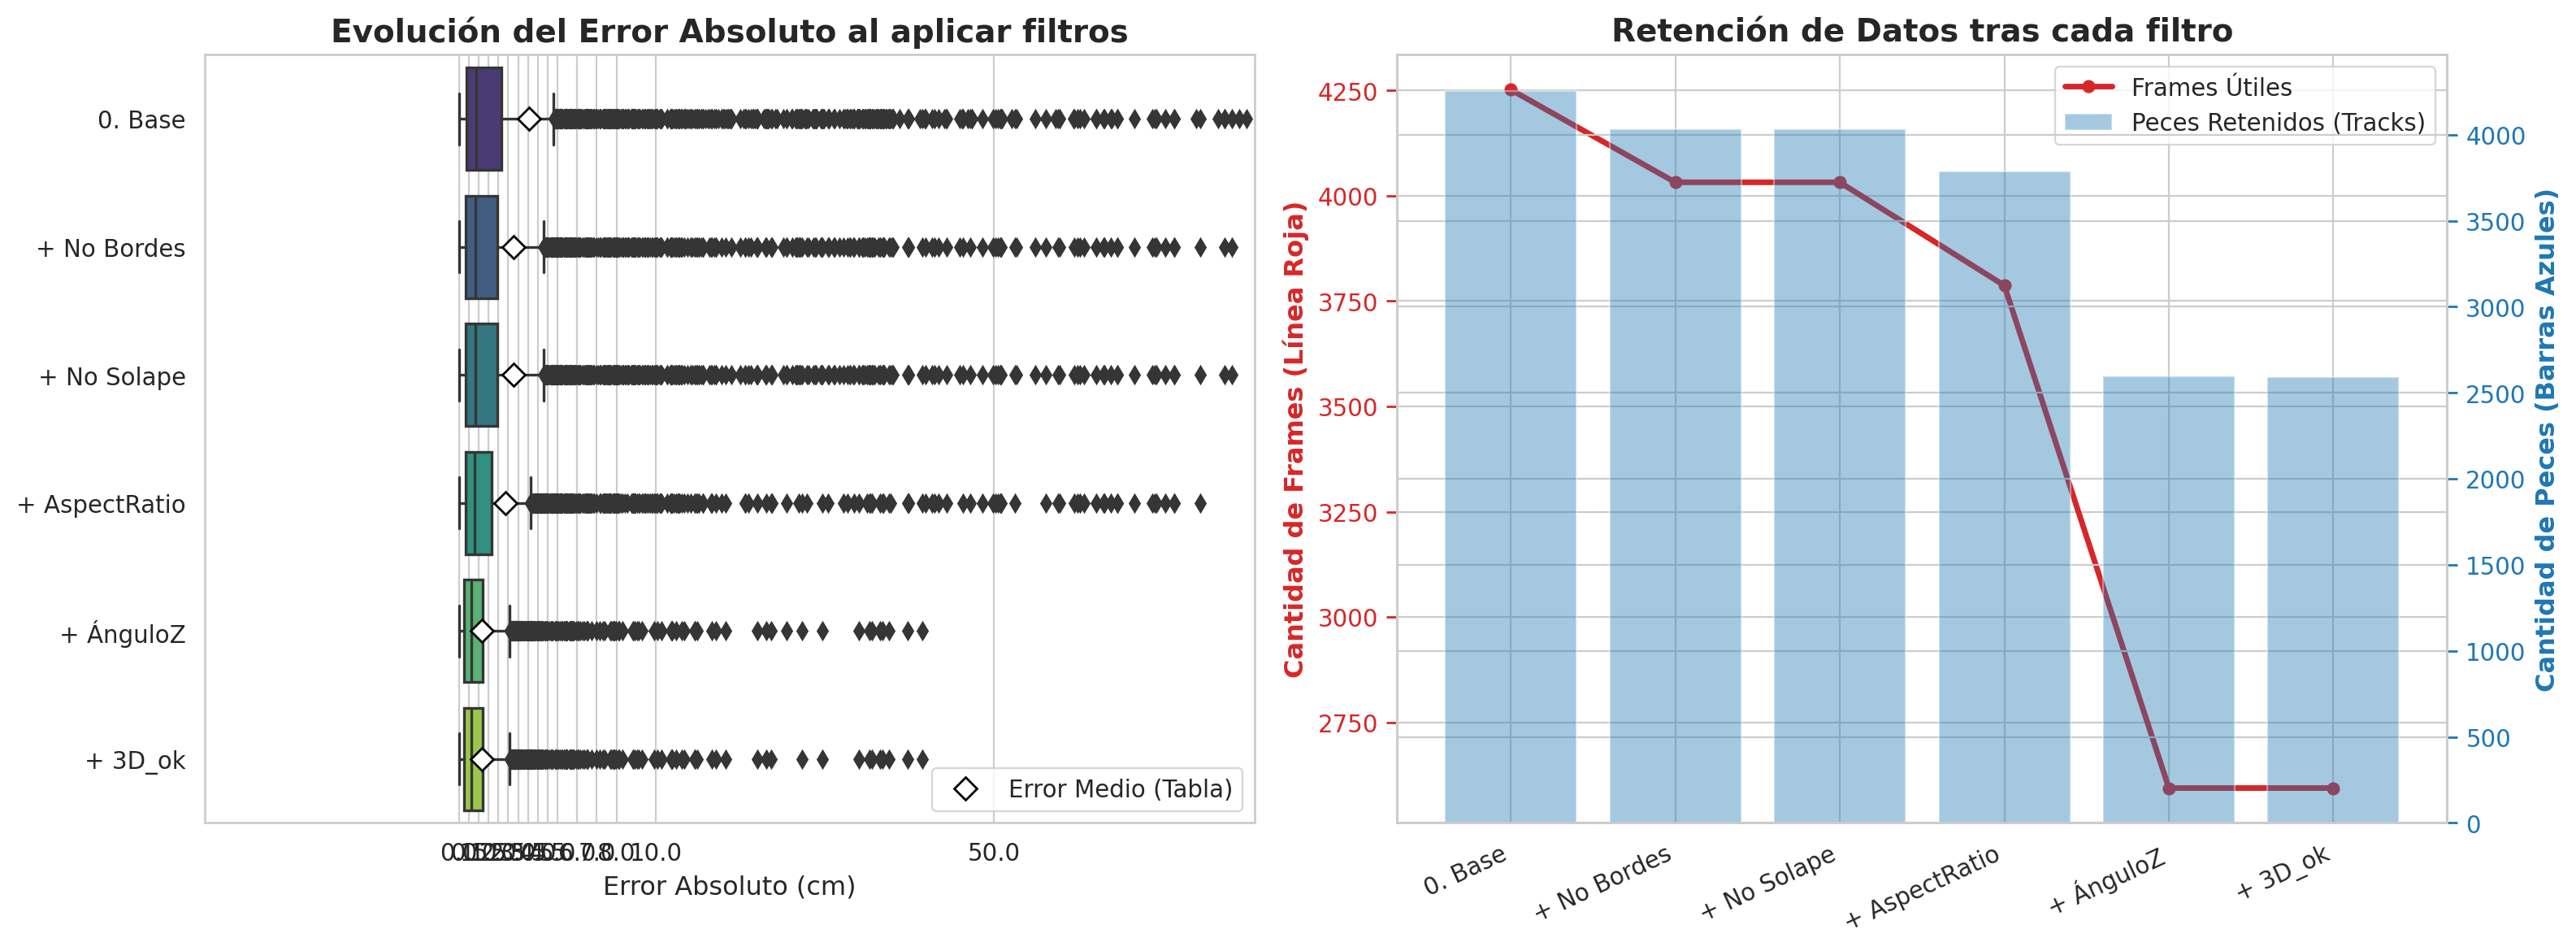

In [11]:
df_names = [
    "df_raw_agg_2024_11_12",
    "df_raw_agg_2024_11_28",
    "df_raw_agg_2025_05_08",
    "df_raw_agg_2025_08_21",
    "df_raw_agg_pool"
]

for df_name in df_names:
    df_raw = globals()[df_name]  # <-- toma el DataFrame real
    cprint(f"DF NAME IS {df_name}","cyan")
    stages_dict, df_filtered_angle_ok = rutils.plot_ablation_pipeline(
        df_raw, ASPECT_RATIO_THR=ASPECT_RATIO_THR, ANGLE_THR=ANGLE_THR
    )

In [ ]:
df_raw_agg_2025_08_21

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,12_09_03,2025_08_21,frame_0,0,255,1,-1,False,False,True,...,NaN,67.619721,37.106544,-1.0,0.322840,0.316668,29.1,3.184030,11.709446,1.663082
1,12_09_03,2025_08_21,frame_1,0,255,1,-1,False,False,True,...,NaN,66.080659,37.133779,-1.0,0.308119,0.328139,29.1,1.711855,6.615414,1.659265
2,12_09_03,2025_08_21,frame_2,0,255,1,-1,False,False,True,...,NaN,50.109826,25.106295,-1.0,0.249701,0.228324,29.1,4.129863,13.598142,1.693085
3,12_09_03,2025_08_21,frame_3,0,255,1,-1,False,False,True,...,NaN,58.247246,14.057908,-1.0,0.300613,0.282332,29.1,0.961328,4.018435,1.678158
4,12_09_03,2025_08_21,frame_4,0,255,1,-1,False,False,True,...,NaN,44.696387,13.541004,-1.0,0.257552,0.244369,29.1,3.344761,10.881526,1.710066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15498,12_07_31,2025_08_21,frame_662,0,255,1,-1,False,False,True,...,NaN,79.294583,-50.546886,-1.0,0.340876,0.338881,29.1,4.987628,17.950270,1.795066
15499,12_07_31,2025_08_21,frame_663,0,255,1,-1,False,False,True,...,NaN,76.837679,-46.298834,-1.0,0.350149,0.356385,29.1,5.914872,21.158726,1.786328
15500,12_07_31,2025_08_21,frame_664,0,255,1,-1,False,False,True,...,NaN,77.656910,-44.845737,-1.0,0.344245,0.336567,29.1,5.324532,19.116027,1.783682
15501,12_07_31,2025_08_21,frame_665,0,255,1,-1,False,False,True,...,NaN,78.717863,-45.519965,-1.0,0.329868,0.334901,29.1,3.886777,14.141098,1.792683
